In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
ROOT_DIR  = Path("D:/Projects/healthcare-xai-cost-prediction")
HOSP_DIR  = ROOT_DIR / "data" / "raw" / "mimic-iv-clinical-database-demo-2.2" / "hosp"
ICU_DIR   = ROOT_DIR / "data" / "raw" / "mimic-iv-clinical-database-demo-2.2" / "icu"
PROC_DIR  = ROOT_DIR / "data" / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

# Load tables
patients      = pd.read_csv(HOSP_DIR / "patients.csv")
admissions    = pd.read_csv(HOSP_DIR / "admissions.csv")
diagnoses     = pd.read_csv(HOSP_DIR / "diagnoses_icd.csv")
procedures    = pd.read_csv(HOSP_DIR / "procedures_icd.csv")
prescriptions = pd.read_csv(HOSP_DIR / "prescriptions.csv")
labevents     = pd.read_csv(HOSP_DIR / "labevents.csv")
drgcodes      = pd.read_csv(HOSP_DIR / "drgcodes.csv")
icustays      = pd.read_csv(ICU_DIR  / "icustays.csv")

print("✅ All tables loaded!")

✅ All tables loaded!


In [3]:
# Convert datetime columns
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
admissions['deathtime'] = pd.to_datetime(admissions['deathtime'])

# Calculate Length of Stay (TARGET VARIABLE 1)
admissions['length_of_stay'] = (
    admissions['dischtime'] - admissions['admittime']
).dt.total_seconds() / (24 * 3600)

# Merge patients + admissions
df = admissions.merge(patients, on='subject_id', how='left')

print(f"Base dataframe shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
display(df.head(3))

Base dataframe shape: (275, 22)
Columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag', 'length_of_stay', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,race,edregtime,edouttime,hospital_expire_flag,length_of_stay,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaT,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,...,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0,8.975000,M,47,2196,2014 - 2016,NaN
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaT,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,...,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0,7.841667,M,58,2153,2011 - 2013,NaN
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaT,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,...,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0,5.731250,M,79,2133,2011 - 2013,2134-10-28


In [4]:
# Count diagnoses per admission
diag_count = diagnoses.groupby('hadm_id').agg(
    num_diagnoses = ('seq_num', 'count'),
    max_seq_diag  = ('seq_num', 'max')
).reset_index()

df = df.merge(diag_count, on='hadm_id', how='left')
df['num_diagnoses'] = df['num_diagnoses'].fillna(0)

print(f"Diagnoses feature added!")
print(df[['hadm_id','num_diagnoses']].describe())

Diagnoses feature added!
            hadm_id  num_diagnoses
count  2.750000e+02     275.000000
mean   2.513055e+07      16.385455
std    2.907533e+06       9.014413
min    2.004459e+07       2.000000
25%    2.258313e+07       9.000000
50%    2.517230e+07      14.000000
75%    2.767155e+07      23.000000
max    2.997458e+07      39.000000


In [5]:
proc_count = procedures.groupby('hadm_id').agg(
    num_procedures = ('seq_num', 'count')
).reset_index()

df = df.merge(proc_count, on='hadm_id', how='left')
df['num_procedures'] = df['num_procedures'].fillna(0)

print(f"Procedures feature added!")
print(df[['hadm_id','num_procedures']].describe())

Procedures feature added!
            hadm_id  num_procedures
count  2.750000e+02      275.000000
mean   2.513055e+07        2.625455
std    2.907533e+06        3.559926
min    2.004459e+07        0.000000
25%    2.258313e+07        0.000000
50%    2.517230e+07        1.000000
75%    2.767155e+07        4.000000
max    2.997458e+07       23.000000


In [6]:
rx_count = prescriptions.groupby('hadm_id').agg(
    num_prescriptions = ('pharmacy_id', 'count'),
    unique_drugs      = ('drug', 'nunique')
).reset_index()

df = df.merge(rx_count, on='hadm_id', how='left')
df['num_prescriptions'] = df['num_prescriptions'].fillna(0)
df['unique_drugs']      = df['unique_drugs'].fillna(0)

print(f"Prescriptions feature added!")
print(df[['hadm_id','num_prescriptions','unique_drugs']].describe())

Prescriptions feature added!
            hadm_id  num_prescriptions  unique_drugs
count  2.750000e+02         275.000000    275.000000
mean   2.513055e+07          65.770909     31.083636
std    2.907533e+06          60.946505     19.254640
min    2.004459e+07           0.000000      0.000000
25%    2.258313e+07          25.000000     19.000000
50%    2.517230e+07          48.000000     28.000000
75%    2.767155e+07          92.000000     43.000000
max    2.997458e+07         348.000000    109.000000


In [7]:
lab_count = labevents.groupby('hadm_id').agg(
    num_lab_tests  = ('labevent_id', 'count'),
    abnormal_labs  = ('flag', lambda x: (x == 'abnormal').sum())
).reset_index()

df = df.merge(lab_count, on='hadm_id', how='left')
df['num_lab_tests'] = df['num_lab_tests'].fillna(0)
df['abnormal_labs'] = df['abnormal_labs'].fillna(0)

print(f"Lab events feature added!")
print(df[['hadm_id','num_lab_tests','abnormal_labs']].describe())

Lab events feature added!
            hadm_id  num_lab_tests  abnormal_labs
count  2.750000e+02     275.000000     275.000000
mean   2.513055e+07     288.389091     113.392727
std    2.907533e+06     390.057021     171.837043
min    2.004459e+07       0.000000       0.000000
25%    2.258313e+07      63.000000      17.500000
50%    2.517230e+07     163.000000      55.000000
75%    2.767155e+07     350.500000     123.500000
max    2.997458e+07    2538.000000    1208.000000


In [8]:
# ICU stays per admission
icu_info = icustays.groupby('hadm_id').agg(
    icu_admission  = ('stay_id', 'count'),
    total_icu_los  = ('los', 'sum'),
    num_icu_stays  = ('stay_id', 'nunique')
).reset_index()
icu_info.rename(columns={'icu_admission': 'num_icu_admissions'}, inplace=True)

df = df.merge(icu_info, on='hadm_id', how='left')
df['icu_admission']     = (df['num_icu_admissions'] > 0).astype(int)
df['total_icu_los']     = df['total_icu_los'].fillna(0)
df['num_icu_admissions']= df['num_icu_admissions'].fillna(0)
df['num_icu_stays']     = df['num_icu_stays'].fillna(0)

print(f"ICU features added!")
print(f"ICU admissions: {df['icu_admission'].sum()} out of {len(df)}")

ICU features added!
ICU admissions: 128 out of 275


In [9]:
# APR DRG only (has severity & mortality)
apr_drg = drgcodes[drgcodes['drg_type'] == 'APR'].copy()
apr_drg = apr_drg.groupby('hadm_id').agg(
    drg_severity  = ('drg_severity', 'max'),
    drg_mortality = ('drg_mortality', 'max')
).reset_index()

df = df.merge(apr_drg, on='hadm_id', how='left')
df['drg_severity']  = df['drg_severity'].fillna(df['drg_severity'].median())
df['drg_mortality'] = df['drg_mortality'].fillna(df['drg_mortality'].median())

print(f"DRG severity features added!")
print(df[['drg_severity','drg_mortality']].describe())

DRG severity features added!
       drg_severity  drg_mortality
count    275.000000     275.000000
mean       2.843636       2.378182
std        0.806625       0.964079
min        1.000000       1.000000
25%        2.000000       2.000000
50%        3.000000       2.000000
75%        3.000000       3.000000
max        4.000000       4.000000


In [10]:
# Binary: hospital expire flag
df['died_in_hospital'] = df['hospital_expire_flag'].astype(int)

# Binary: ED admission
df['ed_admission'] = df['admission_location'].str.contains(
    'EMERGENCY', na=False).astype(int)

# Encode gender
df['gender_encoded'] = (df['gender'] == 'M').astype(int)

# Encode insurance
insurance_map = {'Medicare': 0, 'Medicaid': 1, 'Other': 2}
df['insurance_encoded'] = df['insurance'].map(insurance_map).fillna(2)

# Encode admission type
adm_type_map = {
    'EW EMER.'                      : 0,
    'URGENT'                        : 1,
    'ELECTIVE'                      : 2,
    'OBSERVATION ADMIT'             : 3,
    'EU OBSERVATION'                : 3,
    'DIRECT EMER.'                  : 0,
    'SURGICAL SAME DAY ADMISSION'   : 2,
    'DIRECT OBSERVATION'            : 3,
    'AMBULATORY OBSERVATION'        : 3
}
df['admission_type_encoded'] = df['admission_type'].map(adm_type_map).fillna(3)

print("✅ Categorical encoding done!")
print(df[['gender_encoded','insurance_encoded',
          'admission_type_encoded']].value_counts().head(10))

✅ Categorical encoding done!
gender_encoded  insurance_encoded  admission_type_encoded
1               2                  0                         36
                                   3                         28
0               2                  0                         28
                0                  0                         26
                                   3                         23
                2                  3                         20
1               0                  0                         19
                                   3                         10
0               2                  2                         10
1               2                  2                          9
Name: count, dtype: int64


In [11]:
# TARGET 1: Length of Stay (regression)
# TARGET 2: LOS Category (classification)
df['los_category'] = pd.cut(
    df['length_of_stay'],
    bins  = [0, 2, 7, 14, float('inf')],
    labels= ['Short(0-2d)', 'Medium(3-7d)', 'Long(8-14d)', 'VeryLong(14+d)']
)

# TARGET 3: High Cost Proxy (DRG severity based)
df['high_severity'] = (df['drg_severity'] >= 3).astype(int)

print("TARGET VARIABLES")
print("="*50)
print(f"\nLOS Distribution:\n{df['los_category'].value_counts()}")
print(f"\nHigh Severity:\n{df['high_severity'].value_counts()}")
print(f"\nDied in Hospital:\n{df['died_in_hospital'].value_counts()}")

TARGET VARIABLES

LOS Distribution:
los_category
Medium(3-7d)      129
Long(8-14d)        60
Short(0-2d)        55
VeryLong(14+d)     31
Name: count, dtype: int64

High Severity:
high_severity
1    195
0     80
Name: count, dtype: int64

Died in Hospital:
died_in_hospital
0    260
1     15
Name: count, dtype: int64


In [12]:
# Select final features
FEATURES = [
    # Demographics
    'anchor_age', 'gender_encoded', 'insurance_encoded',
    # Admission info
    'admission_type_encoded', 'ed_admission',
    # Clinical complexity
    'num_diagnoses', 'num_procedures', 'num_prescriptions',
    'unique_drugs', 'num_lab_tests', 'abnormal_labs',
    # ICU
    'icu_admission', 'total_icu_los', 'num_icu_stays',
    # Severity
    'drg_severity', 'drg_mortality'
]

TARGETS = ['length_of_stay', 'los_category', 'high_severity', 'died_in_hospital']

# Final dataframe
df_final = df[['subject_id', 'hadm_id'] + FEATURES + TARGETS].copy()

# Remove rows with LOS <= 0
df_final = df_final[df_final['length_of_stay'] > 0]

print(f"Final dataset shape: {df_final.shape}")
print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"\nTargets: {TARGETS}")
print(f"\nMissing values:\n{df_final.isnull().sum()}")

Final dataset shape: (275, 22)

Features (16): ['anchor_age', 'gender_encoded', 'insurance_encoded', 'admission_type_encoded', 'ed_admission', 'num_diagnoses', 'num_procedures', 'num_prescriptions', 'unique_drugs', 'num_lab_tests', 'abnormal_labs', 'icu_admission', 'total_icu_los', 'num_icu_stays', 'drg_severity', 'drg_mortality']

Targets: ['length_of_stay', 'los_category', 'high_severity', 'died_in_hospital']

Missing values:
subject_id                0
hadm_id                   0
anchor_age                0
gender_encoded            0
insurance_encoded         0
admission_type_encoded    0
ed_admission              0
num_diagnoses             0
num_procedures            0
num_prescriptions         0
unique_drugs              0
num_lab_tests             0
abnormal_labs             0
icu_admission             0
total_icu_los             0
num_icu_stays             0
drg_severity              0
drg_mortality             0
length_of_stay            0
los_category              0
high_sev

In [13]:
# Fill remaining missing values
for col in FEATURES:
    if df_final[col].isnull().sum() > 0:
        if df_final[col].dtype in ['float64', 'int64']:
            df_final[col] = df_final[col].fillna(df_final[col].median())
        else:
            df_final[col] = df_final[col].fillna(df_final[col].mode()[0])

print("After missing value treatment:")
print(df_final.isnull().sum())
print(f"\nFinal shape: {df_final.shape}")

After missing value treatment:
subject_id                0
hadm_id                   0
anchor_age                0
gender_encoded            0
insurance_encoded         0
admission_type_encoded    0
ed_admission              0
num_diagnoses             0
num_procedures            0
num_prescriptions         0
unique_drugs              0
num_lab_tests             0
abnormal_labs             0
icu_admission             0
total_icu_los             0
num_icu_stays             0
drg_severity              0
drg_mortality             0
length_of_stay            0
los_category              0
high_severity             0
died_in_hospital          0
dtype: int64

Final shape: (275, 22)


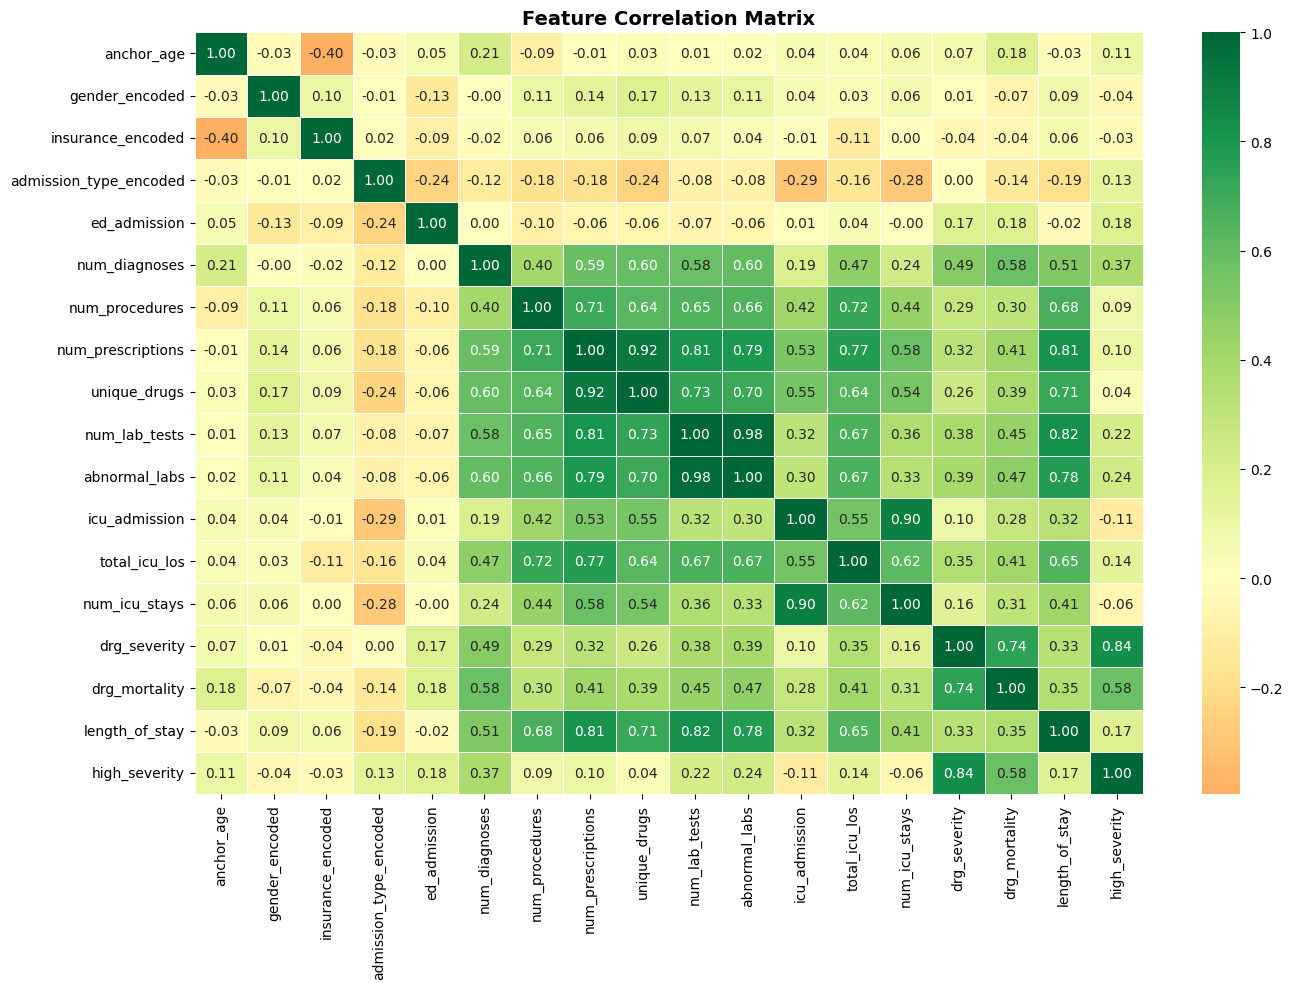

✅ Correlation matrix saved!


In [14]:
REPORTS_DIR = ROOT_DIR / "reports" / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_final[FEATURES + ['length_of_stay', 'high_severity']].corr()

sns.heatmap(
    corr_matrix,
    annot    = True,
    fmt      = '.2f',
    cmap     = 'RdYlGn',
    center   = 0,
    ax       = ax,
    linewidths=0.5
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation matrix saved!")

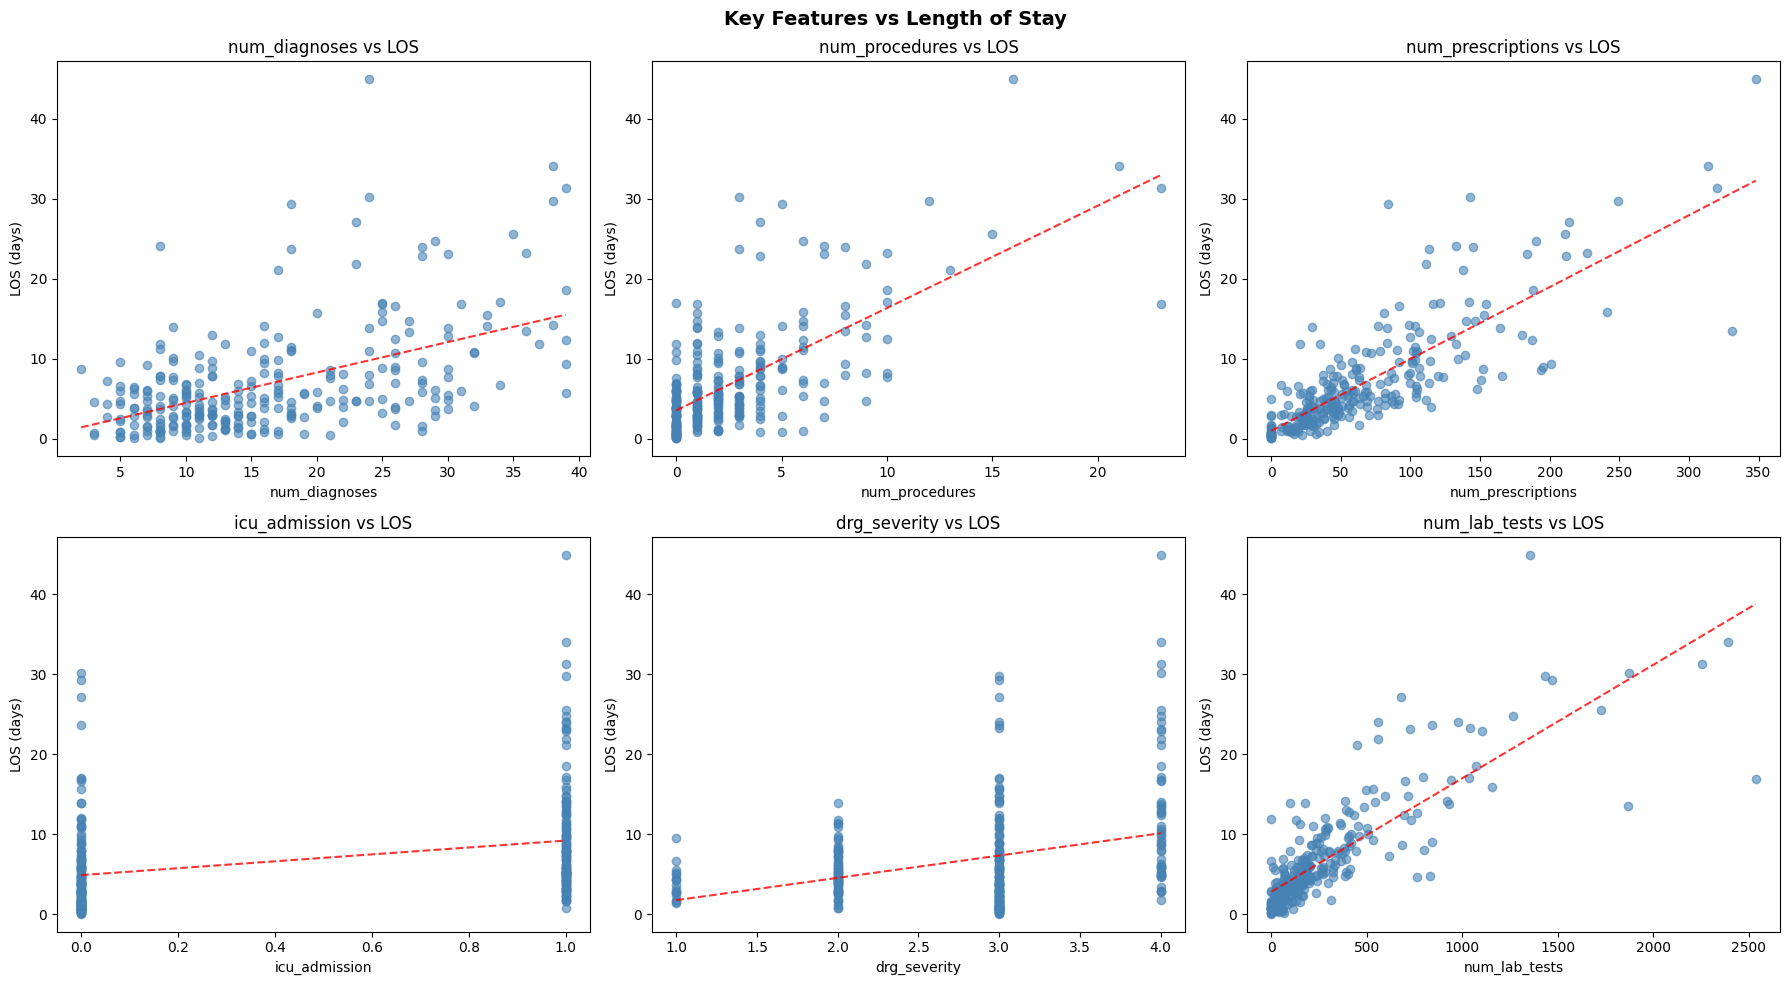

✅ Feature plots saved!


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Features vs Length of Stay', fontsize=14, fontweight='bold')

plot_features = [
    'num_diagnoses', 'num_procedures',
    'num_prescriptions', 'icu_admission',
    'drg_severity', 'num_lab_tests'
]

for idx, feat in enumerate(plot_features):
    ax = axes[idx//3][idx%3]
    ax.scatter(df_final[feat], df_final['length_of_stay'],
               alpha=0.6, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('LOS (days)')
    ax.set_title(f'{feat} vs LOS')

    # Trend line
    z = np.polyfit(df_final[feat].fillna(0),
                   df_final['length_of_stay'].fillna(0), 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_final[feat].min(), df_final[feat].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'features_vs_los.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature plots saved!")

In [16]:
# Save final processed dataset
output_path = PROC_DIR / "mimic_processed.csv"
df_final.to_csv(output_path, index=False)

print("="*60)
print("✅ PREPROCESSING COMPLETE!")
print("="*60)
print(f"📁 Saved to: {output_path}")
print(f"📊 Final shape: {df_final.shape}")
print(f"🎯 Features: {len(FEATURES)}")
print(f"🎯 Targets: {TARGETS}")
print(f"\n📈 LOS Stats:")
print(df_final['length_of_stay'].describe())
print(f"\n▶ Next: Notebook 03 - Model Training")

✅ PREPROCESSING COMPLETE!
📁 Saved to: D:\Projects\healthcare-xai-cost-prediction\data\processed\mimic_processed.csv
📊 Final shape: (275, 22)
🎯 Features: 16
🎯 Targets: ['length_of_stay', 'los_category', 'high_severity', 'died_in_hospital']

📈 LOS Stats:
count    275.000000
mean       6.875530
std        6.733832
min        0.046528
25%        2.692014
50%        4.852778
75%        8.768403
max       44.927778
Name: length_of_stay, dtype: float64

▶ Next: Notebook 03 - Model Training
